# Laboratorio 5: Clasificación 🤗

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos - Primavera 2025</strong></center>


### Cuerpo Docente:

- Profesores: Diego Cortez, Gabriel Iturra
- Auxiliares: Melanie Peña, Valentina Rojas
- Ayudantes: Nicolás Cabello, Cristopher Urbina

### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Juan Muñoz
- Nombre de alumno 2: Arturo Amberg

### **Link de repositorio de GitHub:** [Repositorio](https://github.com/jp835/Repositorio-laboratorio-de-programaci-n-cient-fica-grupo-LosTcg.git)

### Temas a tratar
- Clasificación en problemas desbalanceados
- Lightgbm y xgboost
- Pipelines

## Reglas:

- **Grupos de 2 personas**
- Fecha de entrega: Entregas Martes a las 23:59.
- Instrucciones del lab el viernes a las 16:15 en formato online. Asistencia no es obligatoria, pero se recomienda **fuertemente** asistir.
- <u>Prohibidas las copias</u>. Cualquier intento de copia será debidamente penalizado con el reglamento de la escuela.
- Tienen que subir el laboratorio a u-cursos y a su repositorio de github. Labs que no estén en u-cursos no serán revisados. Recuerden que el repositorio también tiene nota.
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Pueden usar cualquier material del curso que estimen conveniente.





### Objetivos principales del laboratorio
- Comprender cómo trabajar con problemas de clasificación con clases desbalanceadas.
- Aplicar los modelos lightgbm y xgboost.
- Practicar Pipelines

# Parte Teórica [12 puntos]




1. Explique cuál es la diferencia entre los datos de entrenamiento y validación. [1 punto]

2. Explique cuál es el principal desafío al trabajar problemas de clasificación con data no supervisada. [1 punto]

3. Explique en **sus palabras** qué es la matriz de confusión y para qué se utiliza. [1 puntos]

4. Escriba la fórmula de las siguientes métricas y explique con **sus palabras** cómo se interpretan. [1 punto cada uno]

  * Accuracy
  * Precision
  * Recall
  * F1 score

5. Explique qué métrica recomendaría para los siguientes contextos de clasificación. [1 punto cada uno]

  * Mantenimiento predictivo de fallas de maquinaria pesada en la industria minera.  
  * Detección de enfermedades altamente contagiosas.
  * Aprobación de créditos de alto riesgo.
  * Detección de crímenes.

6. Explique qué es la calibración de modelos y para qué se usa. [1 punto]


**Respuesta:**

1. La principal diferencia entre estos dos, que los datos de entrenamiento sirven para, valga la redundancia, entrenar a los modelos, que aprenda los patrones y aprenda a hacer las predicciones. Mientras que los de validación, datos que no estaban en el de entrenamiento, sirven para ajustar los hiperparametros.

2. Como no sabemos lo que estamos buscando, debido a que no tiene labels, no tenemos una forma de decir que esta correcta la clasificación, asi que es muy importante definir de que constituye cada clase.

3. La matriz de confusión es una forma de ejemplificar las correciones correctas e incorrectas con verdaderos positivos, falsos positivos, verdaderos negativos y falsos negativos. A partir de estas metricas se calcula la precision, recall y F1.

4. - Accuracy, que es la suma de verdaderos positivos y verdaderos negativos dividida en todas las predicciones, representa el porcentaje de cantidad total de predicciones correctas.
Accuracy=(VP+VN)/(FP+FN+VP+VN)

   - La precision, que son los verdaderos postivos sobre la suma de verdaderos postivos y falsos positivosm son una forma de ver de la cantidad de positivos que verdaderamente son positivos.
   Precision=VP/(FP+VP)

   - Recall, Verdaderos positivos sobre los verdaderso postivios y los falsos negativos. Y aqui se puede ver que positivos en proporcion fueron correctamente identificados.
   Recall=VP / (VP + FN)

   - Y finalmente el F1 score, una combinación entre precision y recal, se puede decir que es un balance entre estos dos.
   F1 = 2*(Precision*Recall)/(Precisión+Recall).

5. - Para el mantenimiento de maquinarias se recomendaria el recall, ya que se quiere encontrar todas la fallas que pueden pasar. Lo mas importante es poder detectarlas, para poder planificar el cambio, dado que una falla cuesta durante la producción cuesta mas, es decir los falsos negativos son mas graves que un falso positivo.

   - Para la deteccion de enfermedades contagiosas es mas importante el recall, ya que un falso negativo, podra transmitir mas la enfermedad si no esta aislada. Mientras que un falso positivo perjudicaria a solo esa persona.

   - Para los creditos de alto riesgo, es mas importante la precision, ya que, aprobar a una persona que no pueda pagarlo es mas costoso, que rechazar a uno que haya podido pagar. Preferimos no tener falsos positivos que tener falsos negativos.

   - Para la deteccion de crimenes, es mejor la precision, ya que no queremos condenar a un inocente, lo que seria un falso positivo. Por lo que queremos estar lo mas seguro posible que la persona haya cometido el crimen.

6. La calibración de modelos es ajustar las probabilidades del clasificador para que reflejen la verdadera frecuencia observada. Se puede interpretar como la confianza que uno le tiene al clasificador a partir de las probabilidades reales de los eventos.




# Parte práctica [48 puntos]

<p align="center">
  <img src="https://drive.google.com/uc?export=view&id=1BnO4tyh3vM2P199Ec9s3JjngQ4qQ9seP"
" width="300">
</p>


Tras el trágico despido de la mítica mascota de Maipú, Renacín decide adentrarse como consultor en el mercado futbolero, el cuál (para variar...) está cargado en especulaciones.

Como su principal tarea será asesorar a los directivos de los clubes sobre cuál jugador comprar y cuál no, Renacín desea generar modelos predictivos que evaluén distintas características de los jugadores; todo con el fin de tomar decisiones concretas basadas en los datos.

Sin embargo, su condición de corporeo le impidió tomar la versión anterior de MDS7202, por lo que este motivo Renacín contrata a su equipo para lograr su objetivo final. Dado que aún tiene fuertes vínculos con la dirección de deportes de la municipalidad, el corporeo le entrega base de datos con las estadísticas de cada jugador para que su equipo empieze a trabajar ya con un dataset listo para ser usado.


**Los Datos**

Para este laboratorio deberán trabajar con el csv `statsplayers.csv`, donde deberán aplicar algoritmos de aprendizaje supervisado de clasificación en base a características que describen de jugadores de fútbol.

Para comenzar cargue el dataset señalado y a continuación vea el reporte **`Player_Stats_Report.html`** (adjunto en la carpeta del enunciado) que describe las características principales del `DataFrame`.

In [1]:
# Si usted está utilizando Colabolatory le puede ser útil este código para cargar los archivos.
try:
    from google.colab import drive
    drive.mount("/content/drive")
    path = '/content/drive/My Drive/Lab5-2/stats_players.csv'
except:
    print('Ignorando conexión drive-colab')

import pandas as pd
df = pd.read_csv(path)


print(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
                Name Nationality National_Position Club_Position  Height  \
0  Cristiano Ronaldo    Portugal                LS            LW     185   
1       Lionel Messi   Argentina                RW            RW     170   
2             Neymar      Brazil                LW            LW     174   
3        Luis Suárez     Uruguay                LS            ST     182   
4       Manuel Neuer     Germany                GK            GK     193   

   Weight Preffered_Foot  Age        Work_Rate  Weak_foot  ...  Agility  \
0      80          Right   32       High / Low          4  ...       90   
1      72           Left   29  Medium / Medium          4  ...       90   
2      68          Right   25    High / Medium          5  ...       96   
3      85          Right   30    High / Medium          4  ...       86   
4      92          Right   31  Medium /

In [ ]:
df.info()

## 1. Predicción de Seleccionados Nacionales [14 puntos]

<p align="center">
  <img src="https://www.futuro.cl/wp-content/uploads/2016/06/chile-argentina-meme-12.jpg" width="300">
</p>



### 1.1 Preprocesamiento [5 puntos]

Tareas:

1. Genere los labels para la clasificación binaria en una variable llamada `label`. Para esto, trabaje sobre el atributo `National_Position` suponiendo que los valores nulos son jugadores no seleccionados para representar a su país. [Sin puntaje]

2. Hecho esto, ¿cuántos se tienen ejemplos por cada clase? Comente lo que observa. [1 punto]

3. Genere un `ColumnTransformer` en donde especifique las transformaciones que hay que realizar para cada columna (por ejemplo StandarScaler, MinMaxScaler, OneHotEncoder, etc...) para que puedan ser utilizadas correctamente por el modelo predictivo y guárdelo una variable llamada `col_transformer`. [2 puntos]

4. Comente y justifique las transformaciones elegidas sobre cada una de las variables (para esto utilice el material `Player_Stats_Report.html` que viene en el zip del lab), al igual que las transformaciones aplicadas. [2 puntos]

**Respuesta:**

2. Podemos observar que existe un gran desbalanceo entre los jugadores seleccionados, y los no seleccionados, siendo una relacion de 1075 a 16513

4. Primero notamos que la columna Name se puede considerar como un identificador, por lo que para los modelos no se tomara en cuenta. Luego, vemos que las columnas numericas tienen rangos variados, desde 0 a 100, aproximadamente, y de 1 a 5, por lo que es mejor llevarlas todas a una misma escala, por lo que se utilizo un minmax scaler. Luego, vemos que las variables categoricas, sin considerar Name, no tienen orden claro, siendo workrate la que "mas se puede ordenar", pero de manera subjetiva, por lo que para tratar con ellas se utiliza un one-hot encoder. En particular, vemos ademas que solo 2 variables tienen nulos o Nan, que son las poisicones, pero como esto puede ser un dato importante (sin equipo) se consideran como categoria.

In [ ]:
# Manipulación de datos
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
from xgboost import plot_importance
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Preprocesamiento
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, MinMaxScaler
from sklearn.feature_selection import RFE

# Modelado
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Modelos
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Evaluación
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
)


In [2]:


#Si national positions es nan, es 0, y si no es nan, es decir es seleccionado, es 1
df['label'] = np.where(df['National_Position'].isna(), 0, 1)

In [3]:
#Observamos la cantidad de datos por cada clase
df['label'].value_counts()

,count
label,
0,16513
1,1075


In [38]:
numerical_cols_1 = (df.drop('label',axis = 1)).select_dtypes(include=['number']).columns.tolist()

categorical_cols_1 = (df.drop(columns = ['Name','National_Position'],axis = 1)).select_dtypes(exclude=['number']).columns.tolist()



numeric_pipeline_1 = Pipeline([
    ('scaler', MinMaxScaler())
])


categorical_pipeline_1 = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ('scaler', MinMaxScaler())
])


col_transformer_1 = ColumnTransformer([
    ('num', numeric_pipeline_1, numerical_cols_1),
    ('cat', categorical_pipeline_1, categorical_cols_1)
])



### 1.2 Entrenamiento [3 puntos]

Ahora, vamos a entrenar los pipelines generados en los pasos anteriores. Para esto, debe realizar las siguientes tareas:

1. Separe los datos de entrenamiento en un conjunto de entrenamiento y de prueba  (la proporción queda a su juicio). En este paso, seleccione los ejemplos de forma aleatoria e intente mantener la distribución original de labels de cada clase en los conjuntos de prueba/entrenamiento. (vea la documentación de `train_test_split`). [1 puntos]


2. Defina un pipeline llamado `pipeline_xgboost` y otro llamado `pipeline_lightgbm`. Estos pipelines deben tener el mismo ColumnTransformer definido en la sección de preprocesamiento, pero deben variar los clasificadores de acuerdo al nombre de cada pipeline. [1 puntos]

3. Entrene los pipelines. [1 punto]



**Respuesta:**

In [39]:


X = df.drop(['label', 'National_Position','Name'], axis=1)
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [40]:


xgb_pipeline = Pipeline([
    ('preprocessing', col_transformer_1),
    ('classifier', XGBClassifier(eval_metric='logloss'))
])



lgbm_pipeline = Pipeline([
    ('preprocessing', col_transformer_1),
    ('classifier', LGBMClassifier())
])



In [41]:
# Entrenar XGBoost
xgb_pipeline.fit(X_train, y_train)

# Entrenar LightGBM
lgbm_pipeline.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 860, number of negative: 13210
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006645 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2663
[LightGBM] [Info] Number of data points in the train set: 14070, number of used features: 142
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.061123 -> initscore=-2.731797
[LightGBM] [Info] Start training from score -2.731797


Pipeline(memory=None,
         steps=[('preprocessing',
                 ColumnTransformer(n_jobs=None, remainder='drop',
                                   sparse_threshold=0.3,
                                   transformer_weights=None,
                                   transformers=[('num',
                                                  Pipeline(memory=None,
                                                           steps=[('scaler',
                                                                   MinMaxScaler(clip=False,
                                                                                copy=True,
                                                                                feature_range=(0,
                                                                                               1)))],
                                                           verbose=False),
                                                  ['Height', 'Weight', 'Age',
                                                   'Weak_foot', 'Skill_Moves',
                                                   'Ball_Control', 'Dribbling',
                                                   'Ma...
                 LGBMClassifier(boosting_type='gbdt', class_weight=None,
                                colsample_bytree=1.0, importance_type='split',
                                learning_rate=0.1, max_depth=-1,
                                min_child_samples=20, min_child_weight=0.001,
                                min_split_gain=0.0, n_estimators=100,
                                n_jobs=None, num_leaves=31, objective=None,
                                random_state=None, reg_alpha=0.0,
                                reg_lambda=0.0, subsample=1.0,
                                subsample_for_bin=200000, subsample_freq=0))],
         verbose=False)

### 1.3 Resultados [6 puntos]

1. Calcule las métricas accuracy, precisión y recall de la clase positiva (la que indica que un jugador es seleccionado nacional) para evaluar el rendimiento de los distintos modelos. Verifique sus resultados usando `classification_report`. [2 puntos]

2. Explique qué implican los valores de accuracy, precisión y recall de la clase positiva (la que indica que un jugador es seleccionado nacional) y cómo influye la cantidad de ejemplos por clase en los resultados obtenidos. [2 puntos]

3. Explique qué métrica le parece más adecuada y concluya qué modelo tiene un mejor desempeño. [2 puntos]

**Respuesta:**
1. Vemos que los resultados coinciden con las aproximaciones obtenidas de Classification_report

2.  Primero, vemos que el accuracy como se dijo antes, es el porcentaje de predicciones correctas, ya sean de seleccionados o no seleccionados, la precision nos dice cuantas de las predicciones de jugador seleccionado son en efecto un jugador seleccionado, y el recall nos dice cuantos de los seleccionados fue en efecto predicho como seleccionado. Respecto a como afecta la cantidad de ejemplos por clase, vemos que en si, en el recall y precision de la clase objetivo, este no afecta, en terminos de dar un resultado poco representativo, pero, vemos que si afecta al accuracy, pues ya que si la clase son muy desbalanceadas, y el clasificador o predictor predice correctamente la clase 0, que seria la con mayor ejemplos, aunque los TP o true positives sean pocos, este valor sera alto pues esta dominado por los TN o true negatives. Igual recalcar que en terminos generales, es decir en un recall o precision media, ahi si afectaria la diferencia de cantidad de ejemplos, en especial al calcular algo como un weighted averagre

3. Como lo que nos interesa es predecir si un jugador es seleccionado, por lo que la metrica que mas nos interesa seria el precision, ya que queremos la mayor cantidad posible de predicciones correctas

In [42]:
xgb_preds = xgb_pipeline.predict(X_test)
lgbm_preds = lgbm_pipeline.predict(X_test)




print( "Metricas XGBoost:")

accuracy_xgb = accuracy_score(y_test, xgb_preds)
precision_xgb = precision_score(y_test, xgb_preds, pos_label=1)
recall_xgb = recall_score(y_test, xgb_preds, pos_label=1)

print(f"Accuracy: {accuracy_xgb:.4f}")
print(f"Precision (clase positiva): {precision_xgb:.4f}")
print(f"Recall (clase positiva): {recall_xgb:.4f}")
print('------------------------------------------------------')
print("Metricas LightGBM:")

accuracy_lgbm = accuracy_score(y_test, lgbm_preds)
precision_lgbm = precision_score(y_test, lgbm_preds, pos_label=1)
recall_lgbm = recall_score(y_test, lgbm_preds, pos_label=1)

print(f"Accuracy: {accuracy_lgbm:.4f}")
print(f"Precision (clase positiva): {precision_lgbm:.4f}")
print(f"Recall (clase positiva): {recall_lgbm:.4f}")




Metricas XGBoost:
Accuracy: 0.9488
Precision (clase positiva): 0.6471
Recall (clase positiva): 0.3581
------------------------------------------------------
Metricas LightGBM:
Accuracy: 0.9503
Precision (clase positiva): 0.6754
Recall (clase positiva): 0.3581


In [27]:
report = classification_report(y_test, xgb_preds, target_names=['No Seleccionado', 'Seleccionado'])
print('Clasification report xgboost')
print(report)
print('------------------------------------------')
report = classification_report(y_test, lgbm_preds, target_names=['No Seleccionado', 'Seleccionado'])
print('Clasification report lgbm')
print(report)

Clasification report xgboost
                 precision    recall  f1-score   support

No Seleccionado       0.96      0.99      0.97      3303
   Seleccionado       0.65      0.36      0.46       215

       accuracy                           0.95      3518
      macro avg       0.80      0.67      0.72      3518
   weighted avg       0.94      0.95      0.94      3518

------------------------------------------
Clasification report lgbm
                 precision    recall  f1-score   support

No Seleccionado       0.96      0.99      0.97      3303
   Seleccionado       0.68      0.36      0.47       215

       accuracy                           0.95      3518
      macro avg       0.82      0.67      0.72      3518
   weighted avg       0.94      0.95      0.94      3518



2. Accuracy: Ambos modelos tienen un accuracy muy alto, alrededor de 0.95, es decir mayoria de los casos, predice bien. Igual hay que estar pendiente, ya que la clases estan desbalanceadas.

Precision: Aqui se ve que realmente 65%-68% de los seleccionados verdaderamente lo son. Por lo que hay un porcentaje altos de falsos positivos.

Recall: Aqui se ve el recall bajo, aprox 36%, por lo que, solo un tercio de los jugadoes seleccionados realmente lo son seleccionados por el modelo.





## 2. Predicción de posiciones de jugadores [4 puntos]

<p align="center">
  <img src="https://pbs.twimg.com/media/E1rfA1aWEAYU6Ny.jpg" width="300">
</p>

En una nueva jornada de desmesuradas transacciones deportivas, Renacín escuchó a sus colegas discutir acerca de que el precio de cada jugador depende en gran medida de la posición en la cancha en la que juega. Y además, que hay bastantes jugadores nuevos que no tienen muy claro en que posición verdaderamente brillarían, por lo que actualmente puede que actualmente estén jugando en posiciones sub-optimas.

Viendo que los resultados del primer análisis no son tan esperanzadores, el corporeo los comanda a cambiar su tarea: ahora, les solicita que construyan un clasificador enfocado en predecir la mejor posición de los jugadores en la cancha según sus características.

Para lograr esto, primero, les pide que etiqueten de la siguiente manera los valores que aparecen en el atributo `Club_Position`, pidiendo que agrupen los valores en los siguientes grupos:

**Nota**:  Renacín les recalca que **no deben utilizar los valores ```Sub``` y ```Res``` de esta columna**.

```python
ataque = ['ST', 'CF']
central_ataque = ['RW', 'CAM', 'LW']
central = ['RM', 'CM', 'LM']
central_defensa = ['RWB', 'CDM', 'LWB']
defensa = ['RB', 'CB', 'LB']
arquero = ['GK']
```

La elección del clasificador se justificar en base a la siguiente [guía](https://scikit-learn.org/stable/tutorial/machine_learning_map/index.html) y se deben comentar los resultados obtenidos en la clasificación.

**Tareas:** [1 punto por tarea]

1. En un nuevo dataframe, aplique las etiquetas descritas anteriormente en cada uno de los valores señalados en esta sección y guárdelos en la variable `label`.
2. Cuente cuántos por clase quedan.
3. Entrene el nuevo pipeline y ejecute una evaluación de este.  
4. Comente los resultados obtenidos.

1. Respecto al uso del clasificador, como nos encontramos con menos de 100k muestras, en una tarea de clasificacion con variable objetivo, se opto por usar linearsvc para la clasificacion

2. Vemos que por clase tenemos: defensa =	1180;central	907; arquero =	632; central_ataque =	581; ataque	= 430; central_defensa	= 209

4. -  De los resultados obtenidos se pueden ver unos detalles muy claros, en el caso del arquero se predice perfectamente, acertando 126 de las 126 ocaciones. También, en caso de los defensas se puede ver que en gran mayoria de los casos acierta, 228 correctos y 8 malos aciertos. Ahora, siguiendo con el analisis de los centrales se puede ver que el modelo ya tienen dificultades, en especial comparando centrales de ataque y central, en el que se confunde 63 veces con un central de ataque y 29 veces inversamente. Tambien se puede ver un parecido entre central defensa y un defensa ya que su comportamiento es parecido en este caso, el modelo piensa que 2 centrales defensivos son defensas y solo 5 son centrales defensa. Finalmente analizando a los de ataque, mayoria de las veces si lo predice correctamente, llegando a 77 veces.

   - Respecto a las metricas, vemos que se tienen valores aceptables y similares de recall, precision y accuracy, estando en torno a 0.73, lo cual nos hace inferir que es un modelo con un. buen desempeño, ya que incluso el recall y precision promedio, sin considerar pesos de clases, estan por sobre a 0.64

   - A partir de esto, se podria decir que el algoritmo es bueno para predecir 3 casos de forma consistente, arquero, defensa y ataque, pero habria que tener cuidado con los resultados de centrales, lo cual tiene sentido desde el punto de vista de que son posiciones entre las otras 3, y viendo como se comporto la matriz de confusion.

   - Esto responde a la pregunta 4 (todo lo de arriba)

**Respuesta:**

In [14]:
df_2 = df.copy()
posiciones_agrupadas = {
    'ST': 'ataque',
    'CF': 'ataque',

    'RW': 'central_ataque',
    'CAM': 'central_ataque',
    'LW': 'central_ataque',

    'RM': 'central',
    'CM': 'central',
    'LM': 'central',

    'RWB': 'central_defensa',
    'CDM': 'central_defensa',
    'LWB': 'central_defensa',

    'RB': 'defensa',
    'CB': 'defensa',
    'LB': 'defensa',

    'GK': 'arquero'
}



df_2['label'] = df_2['Club_Position'].map(posiciones_agrupadas)
df_2 = df_2.dropna(subset=['label'])
df_2['label'].value_counts()



,count
label,
defensa,1180
central,907
arquero,632
central_ataque,581
ataque,430
central_defensa,209


In [15]:
X = df_2.drop(columns = ['label','Club_Position','Nationality'],axis = 1)


numerical_cols = X.select_dtypes(include=['number']).columns.tolist()

categorical_cols = X.select_dtypes(exclude=['number']).columns.tolist()
print(numerical_cols)
print(categorical_cols)

['Height', 'Weight', 'Age', 'Weak_foot', 'Skill_Moves', 'Ball_Control', 'Dribbling', 'Marking', 'Sliding_Tackle', 'Standing_Tackle', 'Aggression', 'Reactions', 'Interceptions', 'Vision', 'Composure', 'Crossing', 'Short_Pass', 'Long_Pass', 'Acceleration', 'Speed', 'Stamina', 'Strength', 'Balance', 'Agility', 'Jumping', 'Heading', 'Shot_Power', 'Finishing', 'Long_Shots', 'Curve', 'Freekick_Accuracy', 'Penalties', 'Volleys']
['Name', 'National_Position', 'Preffered_Foot', 'Work_Rate']


/usr/local/lib/python3.11/dist-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


Metricas linearsvc:
Accuracy: 0.7386
Precision: 0.7143
Recall: 0.7386
Clasification report lvc
                 precision    recall  f1-score   support

        arquero       1.00      1.00      1.00       126
         ataque       0.74      0.90      0.81        86
        central       0.57      0.63      0.60       182
 central_ataque       0.49      0.27      0.35       116
central_defensa       0.56      0.12      0.20        42
        defensa       0.80      0.97      0.87       236

       accuracy                           0.74       788
      macro avg       0.69      0.65      0.64       788
   weighted avg       0.71      0.74      0.71       788



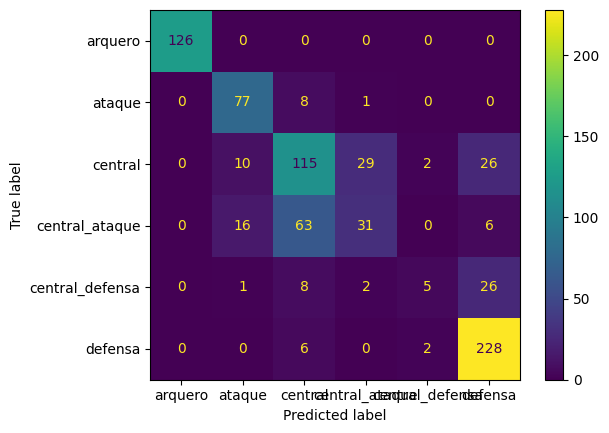

In [16]:


numeric_pipeline = Pipeline([
    ('scaler', MinMaxScaler())
])


categorical_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ('scaler', MinMaxScaler())
])


col_transformer_2 = ColumnTransformer([
    ('num', numeric_pipeline, numerical_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

X_transformed = col_transformer_2.fit_transform(X)

from sklearn.svm import LinearSVC

y = df_2['label']


linearsvc_pipeline = Pipeline([
    ('preprocessing', col_transformer_2),
    ('classifier', LinearSVC(max_iter=5000))
])


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

linearsvc_pipeline.fit(X_train, y_train)



y_pred = linearsvc_pipeline.predict(X_test)


cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=linearsvc_pipeline.classes_)
disp.plot()

print( "Metricas linearsvc:")

accuracy_xgb = accuracy_score(y_test, y_pred)
precision_xgb = precision_score(y_test, y_pred, average='weighted')
recall_xgb = recall_score(y_test, y_pred, average='weighted')
print(f"Accuracy: {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall: {recall_xgb:.4f}")


report = classification_report(y_test, y_pred)
print('Clasification report lvc')
print(report)


## 3. Predicciones de Seleccionados Nacionales para el Jere Klein [30 puntos]

<center>
<img src='https://www.radioactiva.cl/wp-content/uploads/2024/04/Jere-Klein-1-768x432.webp' width=500 />

Después de alcanzar la fama como cantante urbano, Jere Klein decide explorar una nueva faceta. Con su amor por el fútbol y convencido de que los artistas urbanos poseen un talento y versatilidad excepcionales, Jere se embarca en un proyecto innovador: desarrollar un sistema de inteligencia artificial capaz de identificar a jugadores que tienen potencial para convertirse en futbolistas profesionales. Su teoría es que muchos artistas del género urbano chileno, con sus habilidades únicas y su disciplina, podrían destacarse también en el deporte. Con este sistema, Jere espera no solo abrir nuevas oportunidades para sus colegas artistas, sino también demostrar la amplia gama de talentos que pueden ofrecer.

### 2.1 ¿Qué modelo de árbol es más de "pana"? [10 puntos]

<center>
<img src='https://64.media.tumblr.com/39189215a7d3d96823cb359f35b44e05/tumblr_psmrhrR3Xw1qf5hjqo4_540.gif' width=300 />


**Tareas**


1. Considerando el la variable llamada `label` creada en la sección 1.1. Para determinar cuál modelo de árbol sería más adecuado para la tarea en cuestión, utilice PyCaret. Este deberá centrarse exclusivamente en modelos de tipo árbol. Jere ha especificado que busca un modelo que tome decisiones rápidamente y que tenga una baja tasa de falsos positivos, ya que planea invertir en estos jugadores. [3 puntos]

Para la comparación, utilice los siguientes modelos:

```python
['et', 'rf', 'dt', 'xgboost', 'lightgbm', 'catboost']
```

2. Explique en brevemente que son los modelos de la siguiente lista `['et', 'rf', 'dt']` y como funcionan. [3 punto]

3. Tras realizar la comparación de modelos, seleccione aquel que muestre el mejor rendimiento en términos de velocidad y precisión, especialmente en la reducción de falsos positivos. Utilice la función `evaluate_model` de PyCaret para revisar y analizar los resultados obtenidos en los siguientes aspectos:

  - **Confusión Matrix**: ¿Cómo se encuentran la tasa de verdaderos positivos y verdaderos negativos?
  - **Threshold**: ¿Es acaso el umbral por defecto del modelo el mejor para las predicciones?
  - **Feature Importance**: ¿Cuáles son las variables con mejor desempeño? ¿A qué podría deberse esto?
  - **Learning Curve**: ¿El modelo presenta algún problema?

  [4 puntos]

**Respuesta**

2. dt, es el decision tree, un modelo en base a arboles que toma decisiones en base a preguntas de las distintas columnas, en cada se va dividiendo y se ajusta acorde a que tan profundo uno lo quiere.

rf, random forest, funciona con arboles y de una forma muy parecida a desicion tree, pero la gran diferencia es que funciona con subconjuntos de los datos pasando por los arboles, y el resultado general de todos es la metrica correcta. Sirve contra el sobreajuste.

et, extra tree, es parecido a random forest, pero las decisiones de los arboles no necesariamente son los optimos, son aleatoreas, ayudando la velocidad del modelo.

3. - vemos que la formula de tvp = (tp)/(tp + fn) = 56/(56 + 267) = 56/323; y la formula de tvn = tn/(fp + tn) = 4929/(25 + 4929) =  4929/4954
   -
   - Notamos que las reacciones, la compostura y la nacionalidad son de las mas importantes, lo cual hace sentido, ya que un aspecto fundamental de un jugador es el control del balon, y el como se mantiene calmo dentro de la cancha y ademas lo que queremos ver es si un jugador es seleccionado en su pias, por lo que el pais del que es, naturalmente tendre gran importancia en si sera o no, ya que puede afectar en el perfil de jugador seleccionado, o en la competencia por puestos
   -Vemos que con la curva de aprendizaje, el modelo realiza un overfiting, ya que en el set de entrenamiento, hay una prediccion perfecta, y ademas, vemos que al aumentar el numero de muestras, el cross-validation score no aumenta significativamente

In [10]:
!pip install pycaret --quiet
!pip install catboost --quiet

In [46]:
from pycaret.datasets import get_data
from pycaret.classification import *
import os
from pycaret.classification import setup, compare_models, evaluate_model

# Dataset: quitamos National_Position y dejamos 'label', y ademas quitamos 'Name' por considerarse una "ID"
df_py = df.drop(columns=['National_Position','Name'])


clf = setup(
    data=df_py,
    target='label',
    preprocess=True,
    normalize=True,
    fold=10
)


mis_modelos = ['dt', 'rf', 'et', 'lightgbm','catboost', 'xgboost']


best_model = compare_models(include=mis_modelos, sort='Precision')

print("Mejor modelo según precisión:", best_model)


evaluate_model(best_model)

,Description,Value
0,Session id,42
1,Target,label
2,Target type,Binary
3,Original data shape,"(17588, 38)"
4,Transformed data shape,"(17588, 46)"
5,Transformed train set shape,"(12311, 46)"
6,Transformed test set shape,"(5277, 46)"
7,Numeric features,33
8,Categorical features,4
9,Rows with missing values,0.0%


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.9441,0.9414,0.1277,0.7593,0.2161,0.2023,0.2931,1.4640
rf,Random Forest Classifier,0.9482,0.9443,0.2567,0.7173,0.3746,0.3540,0.4072,2.6890
lightgbm,Light Gradient Boosting Machine,0.9510,0.9587,0.4377,0.6512,0.5197,0.4951,0.5079,1.7100
catboost,CatBoost Classifier,0.9492,0.9577,0.3977,0.6408,0.4874,0.4623,0.4786,10.8290
xgboost,Extreme Gradient Boosting,0.9488,0.9562,0.4282,0.6223,0.5043,0.4784,0.4893,0.7550
dt,Decision Tree Classifier,0.9279,0.7068,0.4549,0.4197,0.4353,0.3970,0.3980,1.3060


Processing:   0%|          | 0/29 [00:00<?, ?it/s]

Mejor modelo según precisión: ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0, class_weight=None,
                     criterion='gini', max_depth=None, max_features='sqrt',
                     max_leaf_nodes=None, max_samples=None,
                     min_impurity_decrease=0.0, min_samples_leaf=1,
                     min_samples_split=2, min_weight_fraction_leaf=0.0,
                     monotonic_cst=None, n_estimators=100, n_jobs=-1,
                     oob_score=False, random_state=42, verbose=0,
                     warm_start=False)


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### 2.2 Reducción de dimensionalidad [14 puntos]

<center>
<img src='https://i.kym-cdn.com/photos/images/original/002/258/560/668.gif' width=400 />

A pesar de los resultados obtenidos previamente, el manager de Jere ha solicitado el entrenamiento de un modelo de XGBoost utilizando los datos disponibles. Además, se debe proceder a realizar una reducción de dimensionalidad basada en la importancia de las características.

Para llevar a cabo esta tarea:

1. Inicie entrenando un modelo XGBoost con todas las características disponibles. [2 puntos]

2. Una vez el modelo esté entrenado, evalúe y clasifique las características según su importancia de forma descendente. [2 puntos]

3. Utilice esta clasificación para ejecutar una búsqueda recursiva de eliminación de características, eliminando progresivamente las menos importantes y evaluando el impacto en el desempeño del modelo hasta identificar las N características más críticas. [2 puntos]

4. Con este conjunto reducido de características, entrene un nuevo modelo y evalúe su rendimiento. [2 puntos]

5. Posteriormente, responda a las siguientes preguntas para una comprensión más profunda de los cambios y beneficios:

  - ¿El rendimiento del modelo con las características seleccionadas es similar al del modelo original? ¿Cómo se comparan en términos de precisión y robustez? [2 puntos]
  - ¿Cuáles son los beneficios potenciales de eliminar variables del modelo? Considere factores como la simplificación del modelo, reducción del tiempo de entrenamiento, y mejora en la capacidad de generalización. [2 puntos]
  - Comente si el modelo con menor dimensionalidad es más sencillo de explicar. Explique brevemente por qué la eliminación de ciertas características puede facilitar la comprensión y la explicación del comportamiento del modelo. [2 puntos]

Notar que con esta metodologia buscamos encontrar un punto entermedio entre número de festures y desempeño. por esto, si observa que al aumentar festires el aumento es despreciable, puede no considerar agregar más features a su modelo.

**Respuesta**

- Vemos que en terminos de precision, nuestro modelo disminuye, por lo que en general este modelo es peor en comparacion al original, visto en el item 1 de este laboratorio

- En general eliminar variables permite disminuir considerablemente la dimension de un problema, ya sea a la mitad o incluso menos, permitiendo tener modelos mas simples, que pueden ser interpretaods de mejor manera, como por ejemplo si solo son variables numericas y se baja a 3 o 2 dimensiones, lo cual claramente disminuira el tiempo de entrenamiento, y, al necesitar menos variables, este se puede generalizar mejor, pues las relaciones de multiples variables podrian hacer un modelo muy especifico, que no se generalize a casos mas comunes.

- En general si, pues ahora teniendo menos dimensiones, vemos que existen caracteristicas mas determinantes, lo que en este caso, nos hace generar un perfil mas sencillo de jugador seleccionable, ademas que existen ciertas caracteristicas que quizas al ojo humano no son tan sencillas de ver, como los workrates por ejemplo, por lo que quitar estas caracteristicas, que quizas son mucho mas tecnicas, o especificas a la naturaleza del deporte, hacen que el modelo sea mas comprensible, y mas facil de explicar su comportamiento


Ranking de características más importantes:
                           Feature  Importance
11                  num__Reactions    0.032245
191          cat__Club_Position_GK    0.028293
145          cat__Nationality_Peru    0.024556
60       cat__Nationality_China PR    0.024455
101         cat__Nationality_India    0.024164
52       cat__Nationality_Bulgaria    0.023077
49        cat__Nationality_Bolivia    0.022978
59          cat__Nationality_Chile    0.021538
182     cat__Nationality_Venezuela    0.021105
55         cat__Nationality_Canada    0.018616
75          cat__Nationality_Egypt    0.018415
51         cat__Nationality_Brazil    0.017965
74        cat__Nationality_Ecuador    0.016966
92         cat__Nationality_Greece    0.016763
162  cat__Nationality_South Africa    0.016755


<Figure size 1000x600 with 0 Axes>

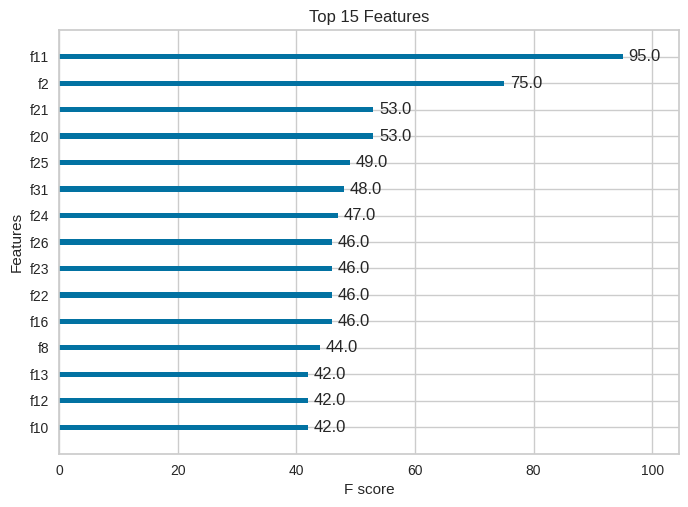


Características seleccionadas por RFE: ['cat__Nationality_Bolivia', 'cat__Nationality_Bulgaria', 'cat__Nationality_Canada', 'cat__Nationality_China PR', 'cat__Nationality_Ecuador', 'cat__Nationality_Egypt', 'cat__Nationality_England', 'cat__Nationality_India', 'cat__Nationality_Japan', 'cat__Nationality_Korea Republic', 'cat__Nationality_Paraguay', 'cat__Nationality_Peru', 'cat__Nationality_Romania', 'cat__Nationality_Saudi Arabia', 'cat__Nationality_Venezuela']

Reporte de clasificación (modelo reducido):
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      3303
           1       0.62      0.15      0.24       215

    accuracy                           0.94      3518
   macro avg       0.78      0.57      0.60      3518
weighted avg       0.93      0.94      0.93      3518

Accuracy reducido: 0.942296759522456


In [47]:



X = df.drop(columns=['label', 'National_Position','Name'], axis=1)
y = df['label']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


xgb_pipeline = Pipeline([
    ('preprocessing', col_transformer_1),
    ('classifier', XGBClassifier(eval_metric='logloss', random_state=42))
])


xgb_pipeline.fit(X_train, y_train)


importances = xgb_pipeline.named_steps['classifier'].feature_importances_
feature_names = xgb_pipeline.named_steps['preprocessing'].get_feature_names_out()

feat_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\nRanking de características más importantes:")
print(feat_importances.head(15))


plt.figure(figsize=(10,6))
plot_importance(xgb_pipeline.named_steps['classifier'], max_num_features=15)
plt.title("Top 15 Features")
plt.show()


X_train_transformed = col_transformer_1.fit_transform(X_train)
X_test_transformed = col_transformer_1.transform(X_test)

# RFE con XGBClassifier
rfe = RFE(
    estimator=XGBClassifier(eval_metric='logloss', random_state=42),
    n_features_to_select=15
)
rfe.fit(X_train_transformed, y_train)


selected_features = feature_names[rfe.support_]
print("\nCaracterísticas seleccionadas por RFE:", selected_features.tolist())


X_train_reduced = X_train_transformed[:, rfe.support_]
X_test_reduced = X_test_transformed[:, rfe.support_]


xgb_reduced = XGBClassifier(eval_metric='logloss', random_state=42)
xgb_reduced.fit(X_train_reduced, y_train)
y_pred = xgb_reduced.predict(X_test_reduced)


print("\nReporte de clasificación (modelo reducido):")
print(classification_report(y_test, y_pred))
print("Accuracy reducido:", accuracy_score(y_test, y_pred))

### 2.3 Calibración Probabilistica [6 puntos]

<center>
<img src='https://media2.giphy.com/media/l2Je4Ku0Cx292KWv6/200w.gif?cid=6c09b952y0sihtq9tb6sz8j2023x3zxxp3qx1ocgonkpkblj&ep=v1_gifs_search&rid=200w.gif&ct=g' width=400 />

Para lograr modelos más modulares, se recomienda realizar una calibración del modelo entrenado anteriormente, con el objetivo de obtener salidas que reflejen mayor modularidad.

1. Se solicita que utilice un método de calibración que asegure que las probabilidades generadas incrementen de manera monótona. Una métrica ampliamente utilizada para evaluar la precisión de la calibración de un modelo es el Brier Score. Calcule el Brier Score para el modelo tanto antes como después de la calibración. Esto le permitirá realizar una comparación cuantitativa y determinar si la calibración ha mejorado el rendimiento del modelo. Para más información sobre el Brier Score, puede consultar el siguiente enlace: [Scikit-Learn - Brier Score Loss](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.brier_score_loss.html). [3 puntos]

2. Tras la calibración, examine y comente los resultados obtenidos. A su análisis añada una comparación visual de las ideales versus las salidas del modelo original (sin calibrar) y del modelo calibrado. [3 puntos]

**Respuesta**

1. Notamos que usamos el metodo "Isotonic" en el metodo "CalibratedClassifierCV", esto pues, como se busca que las probabilidades generadas incrementen de manera monotona, es decir, que si en el modelo sin calibrar p1 < p2, buscamos que $\overline{p1}$ < $\overline{p2}$, donde $\overline{p1}$ es la probabilidad del modelo calibrado. Vemos que como isotonic usa la funcion sigmoide, que es monotonamente creciente, esto se cumplira, respaldados ademas en la documentacion del metodo "CalibratedClassifierCV". De acuerdo al Brier Score, vemos que nuestro modelo calibrado empeoro

2.  Vemos que es un modelo peor de acuerdo a brier score, y ademas vemos que respecto al modelo sin calibrar, tiene metricas casi identicas, por lo que no existe gran diferencia entre ambos modelos, lo cual se puede ver respaldado por las curvas, ya que tanto calibrado como no calibrado tienen un comportamiento similar

Brier Score antes de calibración: 0.0524
Brier Score después de calibración: 0.0525


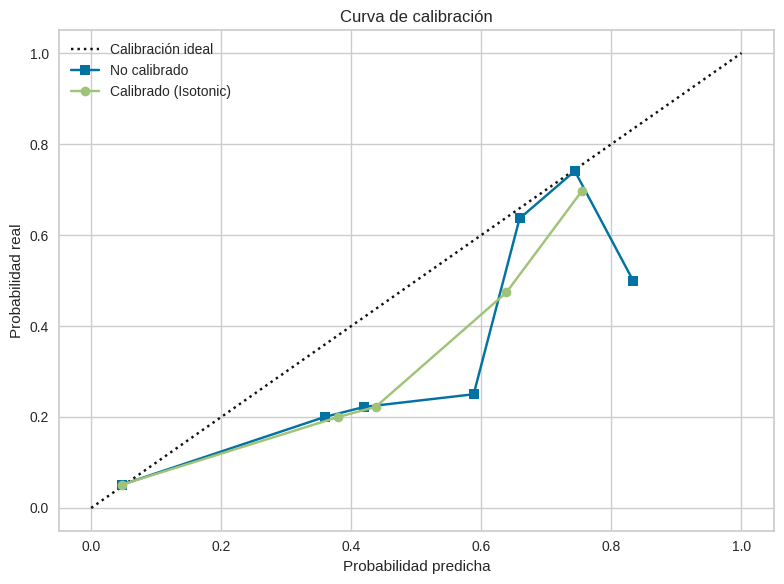


Reporte clasificación (modelo reducido):
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      3303
           1       0.62      0.15      0.24       215

    accuracy                           0.94      3518
   macro avg       0.78      0.57      0.60      3518
weighted avg       0.93      0.94      0.93      3518



In [49]:

from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss


y_prob_sin_calibrar = xgb_reduced.predict_proba(X_test_reduced)[:, 1]
brier_inicial = brier_score_loss(y_test, y_prob_sin_calibrar)
print(f"Brier Score antes de calibración: {brier_inicial:.4f}")


calibrated_model = CalibratedClassifierCV(estimator=xgb_reduced, method='isotonic', cv=5)

calibrated_model.fit(X_train_reduced, y_train)


y_prob_calibrada= calibrated_model.predict_proba(X_test_reduced)[:, 1]
brier_calibrada = brier_score_loss(y_test, y_prob_calibrada)
print(f"Brier Score después de calibración: {brier_calibrada:.4f}")

prob_true_sin_calibrar, prob_pred_sin_calibrar = calibration_curve(
    y_test, y_prob_sin_calibrar, n_bins=10, strategy='uniform')

prob_true_calibrada, prob_pred_calibrada = calibration_curve(
    y_test, y_prob_calibrada, n_bins=10, strategy='uniform')

plt.figure(figsize=(8,6))
plt.plot([0, 1], [0, 1], "k:", label="Calibración ideal")
plt.plot(prob_pred_sin_calibrar, prob_true_sin_calibrar, "s-", label="No calibrado")
plt.plot(prob_pred_calibrada, prob_true_calibrada, "o-", label="Calibrado (Isotonic)")

plt.xlabel("Probabilidad predicha")
plt.ylabel("Probabilidad real")
plt.title("Curva de calibración")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

y_pred_calibrado = calibrated_model.predict(X_test_reduced)
print("\nReporte clasificación (modelo reducido):")
print(classification_report(y_test, y_pred_calibrado))



Mucho éxito!

<center>
<img src="https://i.pinimg.com/originals/55/3d/42/553d42bea9b10e0662a05aa8726fc7f4.gif" width=300>